Step 1: Import Libraries

Import necessary libraries: TensorFlow/Keras for model building, Matplotlib for plotting, NumPy for numerical operations, and Scikit-Learn for evaluation.

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

Step 2: Load Datasets (MNIST & CIFAR-10)

Load both datasets. MNIST will serve as a baseline demonstration, while CIFAR-10 will be our main test case for the ANN.
Define the class names for CIFAR-10.

In [2]:
# Load MNIST dataset
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = datasets.mnist.load_data()
print("--- MNIST Loaded ---")
print("MNIST Train shape:", X_train_mnist.shape) # (60000, 28, 28)

# Load CIFAR-10 dataset
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = datasets.cifar10.load_data()
print("\n--- CIFAR-10 Loaded ---")
print("CIFAR-10 Train shape:", X_train_cifar.shape) # (50000, 32, 32, 3)

# Define CIFAR-10 class names (index corresponds to label)
classes_cifar = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
print("CIFAR-10 Classes:", classes_cifar)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- MNIST Loaded ---
MNIST Train shape: (60000, 28, 28)
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 341s 2us/step

--- CIFAR-10 Loaded ---
CIFAR-10 Train shape: (50000, 32, 32, 3)
CIFAR-10 Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Step 3: Explore Datasets

Visualize sample images from both datasets to understand their differences in complexity (grayscale vs. color, simple digits vs. varied objects).


--- Sample MNIST Images ---


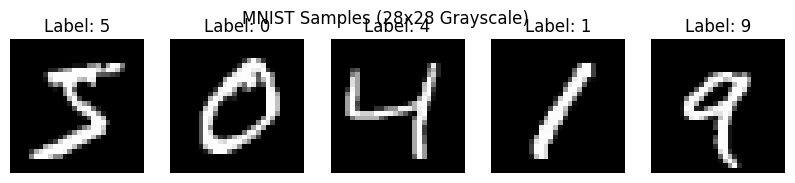


--- Sample CIFAR-10 Images ---


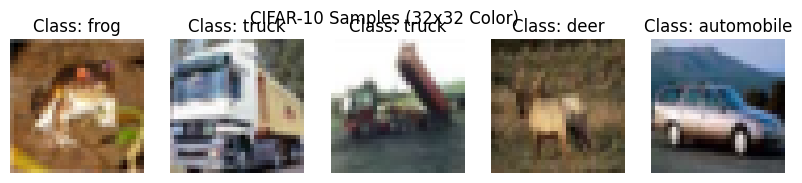


Notice the increased complexity in CIFAR-10 (color, varied objects, backgrounds).


In [3]:
print("\n--- Sample MNIST Images ---")
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1); plt.imshow(X_train_mnist[i], cmap='gray'); plt.title(f"Label: {y_train_mnist[i]}"); plt.axis('off')
plt.suptitle("MNIST Samples (28x28 Grayscale)")
plt.show()

print("\n--- Sample CIFAR-10 Images ---")
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1); plt.imshow(X_train_cifar[i]); plt.title(f"Class: {classes_cifar[y_train_cifar[i][0]]}"); plt.axis('off')
plt.suptitle("CIFAR-10 Samples (32x32 Color)")
plt.show()

print("\nNotice the increased complexity in CIFAR-10 (color, varied objects, backgrounds).")

Step 4: Preprocess Data

Normalization: Scale pixel values to the [0, 1] range for both datasets (refer to Summary Sec 3.2).
Label Reshaping: Ensure CIFAR-10 labels are 1D (refer to Summary Sec 3.2 explanation, even though MNIST labels are usually okay).

In [4]:
print("\n--- Preprocessing Data ---")
# Normalize MNIST
X_train_mnist_norm = X_train_mnist / 255.0
X_test_mnist_norm = X_test_mnist / 255.0
print("MNIST normalization complete.")

# Normalize CIFAR-10
X_train_cifar_norm = X_train_cifar / 255.0
X_test_cifar_norm = X_test_cifar / 255.0
print("CIFAR-10 normalization complete.")

# Reshape CIFAR-10 labels (from (N, 1) to (N,))
y_train_cifar_flat = y_train_cifar.reshape(-1,)
y_test_cifar_flat = y_test_cifar.reshape(-1,)
print("CIFAR-10 labels reshaped:", y_train_cifar_flat.shape)


--- Preprocessing Data ---
MNIST normalization complete.
CIFAR-10 normalization complete.
CIFAR-10 labels reshaped: (50000,)


Step 5: Define the ANN Architecture

Create a function to build our standard ANN model using the Keras Sequential API (refer to Summary Sec 3.3).
This architecture includes:
A Flatten layer to convert the input image into a 1D vector.
A Dense hidden layer with relu activation (refer to Summary Sec 2.5).
A Dense output layer with softmax activation for multi-class classification (refer to Summary Sec 2.5).
We will use this same function to create models for both MNIST and CIFAR-10, changing only the input shape.

In [5]:
def build_ann_model(input_shape, num_classes, hidden_units=128):
  """Builds a simple sequential ANN model."""
  model = models.Sequential([
      # Flatten layer converts image matrix to 1D vector
      layers.Flatten(input_shape=input_shape),
      # Dense hidden layer (fully connected)
      layers.Dense(hidden_units, activation='relu'),
      # Dense output layer (one neuron per class)
      layers.Dense(num_classes, activation='softmax')
  ], name=f"Simple_ANN_{hidden_units}hidden")
  return model

# Example: Define input shapes (Height, Width, [Channels])
# Note: Flatten handles the multiplication internally based on input_shape
input_shape_mnist = (28, 28)   # Grayscale, no channel needed for Flatten input_shape
input_shape_cifar = (32, 32, 3) # Color image requires channel dimension

# Example: Define number of output classes
num_classes_mnist = 10
num_classes_cifar = 10

print("ANN builder function defined.")

ANN builder function defined.


Step 6: Train & Evaluate ANN on MNIST (Baseline)

Build, compile, and train the ANN on the preprocessed MNIST data.
Compile using adam optimizer and sparse_categorical_crossentropy loss (refer to Summary Sec 3.4).
Evaluate its performance on the test set. This serves as our baseline showing ANN effectiveness on simpler image data.
Self-Check: Try to predict the accuracy before revealing the result.

In [6]:
print("\n--- ANN on MNIST (Baseline) ---")

# Build the MNIST ANN model
ann_mnist = build_ann_model(input_shape_mnist, num_classes_mnist)
ann_mnist.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
ann_mnist.summary()

print("\nTraining ANN on MNIST...")
# Train for a few epochs
history_mnist = ann_mnist.fit(X_train_mnist_norm, y_train_mnist,
                              epochs=5,
                              batch_size=32,
                              validation_split=0.1,
                              verbose=1) # Show progress

print("\nEvaluating ANN on MNIST Test Set...")
# --- Try to evaluate yourself first! ---
# What accuracy do you expect based on the summary/previous runs?
# Use: ann_mnist.evaluate(X_test_mnist_norm, y_test_mnist)


--- ANN on MNIST (Baseline) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Simple_ANN_128hidden"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


Training ANN on MNIST...
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9215 - loss: 0.2723 - val_accuracy: 0.9660 - val_loss: 0.1229
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9646 - loss: 0.1189 - val_accuracy: 0.9720 - val_loss: 0.0941
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9764 - loss: 0.0802 - val_accuracy: 0.9765 - val_loss: 0.0849
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9832 - loss: 0.0585 - val_accuracy: 0.9757 - val_loss: 0.0808
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9877 - loss: 0.0432 - val_accuracy: 0.9760 - val_loss: 0.0820

Evaluating ANN on MNIST Test Set...


Step 7: Train & Evaluate SAME ANN on CIFAR-10 (Main Experiment)

Now, build, compile, and train the exact same ANN architecture (only changing the input shape) on the more complex CIFAR-10 data.
Observe the training process and evaluate the final performance.
Self-Check: How well do you expect this simple ANN to perform on CIFAR-10 compared to MNIST? Why?

In [7]:
print("\n--- ANN on CIFAR-10 (Main Experiment) ---")

# Build the CIFAR-10 ANN model using the SAME builder function
ann_cifar = build_ann_model(input_shape_cifar, num_classes_cifar)
ann_cifar.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy', # Still integer labels
                   metrics=['accuracy'])
ann_cifar.summary() # Note the much larger number of params in Flatten/Dense due to 32x32x3 input

print("\nTraining ANN on CIFAR-10...")
# Train for potentially more epochs, though performance might plateau quickly
history_cifar = ann_cifar.fit(X_train_cifar_norm, y_train_cifar_flat,
                              epochs=10, # Train a bit longer
                              batch_size=32,
                              validation_split=0.1,
                              verbose=1)

print("\nEvaluating ANN on CIFAR-10 Test Set...")
# --- Try to evaluate yourself first! ---
# What accuracy do you expect now? Compare it to the MNIST result.
# Use: ann_cifar.evaluate(X_test_cifar_norm, y_test_cifar_flat)


--- ANN on CIFAR-10 (Main Experiment) ---


Model: "Simple_ANN_128hidden"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

 Non-trainable params: 0 (0.00 B)


Training ANN on CIFAR-10...
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3152 - loss: 1.9080 - val_accuracy: 0.3410 - val_loss: 1.8189
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3727 - loss: 1.7543 - val_accuracy: 0.3704 - val_loss: 1.7540
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3950 - loss: 1.7008 - val_accuracy: 0.3886 - val_loss: 1.7165
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4072 - loss: 1.6684 - val_accuracy: 0.4062 - val_loss: 1.6888
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4174 - loss: 1.6455 - val_accuracy: 0.4054 - val_loss: 1.6807
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4218 - loss: 1.6282 - val_accuracy: 0.3996 - val_loss: 1.6762
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4264 - loss: 1.6140 - val_accuracy: 0.4052 - val_loss: 1.6670
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accur

Step 8: Compare Performance & Discuss Limitations

Explicitly compare the test accuracies achieved by the same ANN architecture on MNIST vs. CIFAR-10.
Relate the performance drop on CIFAR-10 to the inherent limitations of ANNs for image data discussed in Summary Section VI.

In [8]:
print("\n--- Performance Comparison ---")

# Ensure you have run the evaluate code inside the <details> sections above
# If you encounter a NameError, go back and run the evaluate code in the hidden sections.
try:
    print(f"MNIST ANN Test Accuracy:      {accuracy_mnist:.4f}")
except NameError:
    print("MNIST accuracy variable ('accuracy_mnist') not found. Please run the evaluation in Step 6 <details>.")

try:
    print(f"CIFAR-10 ANN Test Accuracy:   {accuracy_cifar:.4f}")
except NameError:
    print("CIFAR-10 accuracy variable ('accuracy_cifar') not found. Please run the evaluation in Step 7 <details>.")

print("\n--- Discussion ---")
print("Observe the significant drop in accuracy when applying the same ANN to CIFAR-10.")
print("This highlights the limitations of simple ANNs for complex image tasks:")
print("1. Loss of Spatial Information: The Flatten layer discards the 2D/3D structure of pixels.")
print("2. Parameter Inefficiency: Dense layers connect every input pixel to every neuron, leading")
print("   to a very large number of parameters for images (compare model summaries).")
print("3. Lack of Translation Invariance: The ANN learns features based on absolute pixel positions,")
print("   making it sensitive to shifts or distortions in the object's location.")
print("\nThese challenges motivate the need for architectures specifically designed for spatial data.")


--- Performance Comparison ---
MNIST accuracy variable ('accuracy_mnist') not found. Please run the evaluation in Step 6 <details>.
CIFAR-10 accuracy variable ('accuracy_cifar') not found. Please run the evaluation in Step 7 <details>.

--- Discussion ---
Observe the significant drop in accuracy when applying the same ANN to CIFAR-10.
This highlights the limitations of simple ANNs for complex image tasks:
1. Loss of Spatial Information: The Flatten layer discards the 2D/3D structure of pixels.
2. Parameter Inefficiency: Dense layers connect every input pixel to every neuron, leading
   to a very large number of parameters for images (compare model summaries).
3. Lack of Translation Invariance: The ANN learns features based on absolute pixel positions,
   making it sensitive to shifts or distortions in the object's location.

These challenges motivate the need for architectures specifically designed for spatial data.


Step 9: Conclusion & Next Steps

Summary of the key finding: standard ANNs, while effective on simple datasets like MNIST, struggle with more complex image data like CIFAR-10 due to their inability to process spatial information efficiently.
This limitation provides the motivation for Part 2, where we will introduce Convolutional Neural Networks (CNNs) as a solution designed to overcome these issues.


In [9]:
print("\n--- Conclusion ---")
print("This lab demonstrated that while ANNs can classify simple images like MNIST digits,")
print("their performance significantly degrades on more complex, real-world image datasets")
print("like CIFAR-10. This is primarily because they fail to leverage the spatial")
print("structure inherent in images.")
print("\n--- Next Steps ---")
print("In Part 2, we will explore Convolutional Neural Networks (CNNs), an architecture")
print("specifically developed to effectively process spatial data and achieve much")
print("better performance on image recognition tasks.")


--- Conclusion ---
This lab demonstrated that while ANNs can classify simple images like MNIST digits,
their performance significantly degrades on more complex, real-world image datasets
like CIFAR-10. This is primarily because they fail to leverage the spatial
structure inherent in images.

--- Next Steps ---
In Part 2, we will explore Convolutional Neural Networks (CNNs), an architecture
specifically developed to effectively process spatial data and achieve much
better performance on image recognition tasks.


Step 10: Discussion

Reflect on the steps performed in this lab and discuss the following questions with your group. You can use the Part 1 Summary document and Large Language Models (LLMs) to help explore concepts further, but try to formulate your own understanding first.

What are the key differences between the MNIST and CIFAR-10 datasets used in this lab (consider image size, color channels, and content complexity)?
Why was normalization (dividing pixel values by 255.0) applied to both datasets in Step 4? What issue might arise if we didn't normalize? (Refer to Summary Sec 3.2)
Explain the purpose of the layers.Flatten layer used as the first layer in the build_ann_model function (Step 5). Why is it necessary for a standard ANN processing image data? (Refer to Summary Sec VI)
The hidden layer in the ANN used activation='relu'. What does the ReLU activation function do, and why is it commonly used in hidden layers? (Refer to Summary Sec 2.5)
The output layer used activation='softmax'. What does Softmax do, and why is it suitable for the 10-class classification tasks (MNIST and CIFAR-10)? (Refer to Summary Sec 2.5)
The models were compiled using loss='sparse_categorical_crossentropy'. Why was this specific loss function chosen for these tasks? (Refer to Summary Sec 3.4)
What does the optimizer='adam' do during the model.fit() process? (Refer to Summary Sec 3.4)
Compare the number of trainable parameters shown in the model.summary() output for the MNIST ANN versus the CIFAR-10 ANN (Step 6 vs. Step 7). Why is the number much larger for the CIFAR-10 model, even though the hidden layer size (hidden_units) was the same?
What was the approximate test accuracy achieved by the ANN on MNIST (Step 6)?
What was the approximate test accuracy achieved by the same ANN architecture on CIFAR-10 (Step 7)?
Based on the results from questions 9 and 10, how well did the simple ANN generalize from the MNIST task to the more complex CIFAR-10 task?
What are the main limitations of using a standard ANN (with Flatten and Dense layers) for image classification tasks, as highlighted by the performance difference observed? (Refer to Summary Sec VI)
How does the concept of "loss of spatial information" relate to the Flatten layer?
Why does the "parameter inefficiency" of Dense layers become a bigger problem for CIFAR-10 (32x32x3) compared to MNIST (28x28)?
What is the primary goal of this lab activity in the context of learning about image recognition models?


Answers

Differences: MNIST has 28x28 pixel grayscale images (1 channel) of simple, centered digits. CIFAR-10 has 32x32 pixel color images (3 channels) of more complex real-world objects with varied backgrounds and positions. CIFAR-10 is significantly more complex visually.
Normalization: It scales pixel values to a smaller range (0 to 1). Neural networks train more effectively and stably with smaller input values, preventing issues where large input values might lead to exploding gradients or slow convergence.
Flatten Layer: It converts the 2D (or 3D for color) image matrix into a 1D vector. Standard Dense layers in an ANN expect 1D input, so flattening is necessary to feed the image data into the fully connected network structure.
ReLU: Rectified Linear Unit outputs the input if it's positive (max(0, x)) and zero otherwise. It introduces non-linearity efficiently and helps prevent the vanishing gradient problem during training in deep networks.
Softmax: It converts the raw output scores (logits) from the 10 output neurons into a probability distribution where each output is between 0 and 1, and all 10 outputs sum to 1. This gives the model's predicted probability for each class.
Loss Function: sparse_categorical_crossentropy is used for multi-class classification when the true labels are provided as single integers (e.g., 0, 1, 2... 9) rather than one-hot encoded vectors. Both MNIST and CIFAR-10 labels were provided as integers in this lab.
Optimizer ('adam'): During training, the optimizer uses the calculated loss to determine how to adjust the model's internal parameters (weights and biases) to improve performance in the next iteration. Adam is an algorithm that adaptively adjusts the learning rate for each parameter.
Parameter Count: The Flatten layer output is much larger for CIFAR-10 (32*32*3 = 3072) than for MNIST (28*28 = 784). Since the first Dense layer connects to every element of the flattened input, the number of connections (weights) between Flatten and the first Dense layer is significantly higher for CIFAR-10, resulting in many more trainable parameters overall.
MNIST Accuracy: The ANN typically achieves high accuracy on MNIST, often around 97-98% after 5 epochs. (Actual value depends on the specific run).
CIFAR-10 Accuracy: The same ANN architecture achieves significantly lower accuracy on CIFAR-10, often around 40-55% after 10 epochs. (Actual value depends on the specific run).
Generalization: The ANN generalizes poorly from the simple MNIST task structure to the more complex CIFAR-10 task. The high accuracy on MNIST doesn't translate to CIFAR-10 using this architecture.
ANN Limitations for Images: 1) Loss of spatial information (due to Flattening), 2) Parameter inefficiency (Dense layers require too many weights for large inputs), 3) Lack of translation invariance (sensitive to object position).
Flatten & Spatial Loss: The Flatten layer takes the grid of pixels (where adjacency matters) and arranges them into a long line, discarding the information about which pixels were originally neighbours horizontally, vertically, or diagonally.
Parameter Inefficiency & Size: The flattened input vector for CIFAR-10 (3072) is about 4 times larger than for MNIST (784). Since the number of weights in the first Dense layer is roughly (input_size * hidden_units), the parameter count scales linearly with the input size, becoming computationally expensive and prone to overfitting much faster for larger/color images.
Goal of Lab: The primary goal is to demonstrate the limitations of standard ANNs for complex image classification and thereby motivate the need for Convolutional Neural Networks (CNNs), which are designed to specifically address these limitations by preserving spatial information and using parameters more efficiently.
